# 1. Problem Statement

**Predict and analyze employee attrition patterns using clustering**

In [41]:
import numpy as np
import pandas as pd
df=pd.read_csv('/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Question: “What patterns lead to employee leaving?”
| Concept         | Meaning                         |
| --------------- | ------------------------------- |
| Input features  | Age, salary, satisfaction, etc. |
| Output (target) | Attrition(yes=employee left ,No=stayed                |


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [43]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# DATASET IS ALREADY:

* Clean 
* Complete 
* Ready for ML BUT SOME CONVERSION REQUIRED

#  Categorical columns

Examples:

* Department
* JobRole
* Gender
* OverTime

* Meaning:
These are text values → we must convert them into numbers before ML

# Useless / constant columns:

We should REMOVE them:

1. EmployeeCount

 always = 1 → no meaning

2. StandardHours

 always = 80 → no variation → useless

3. Over18

 always = Y → no information

4. EmployeeNumber

 just ID → not useful for patterns

 *Only meaningful patterns remain for clustering”***

# Data cleaning for clustring(remove unwanted columns)

In [44]:
df.drop(['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], axis=1, inplace=True)

# handle yes/no clumns

In [45]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})


In [46]:
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# Handle MULTI-CATEGORY columns by ONE-HOT ENCODING

* Department (3 types)
* JobRole (many types)
* MaritalStatus
* BusinessTravel

In [47]:
df=pd.get_dummies(df,drop_first=True)
# pd.get_dummies()
# converts all categorical columns into binary columns (0/1)
# drop_first=True
 # removes one column from each category to avoid duplication
# Why?
# Because:
# If we know 2 columns, 3rd is automatically known → redundant
df = df.astype(int)
df.shape

(1470, 45)

* before:
> Department = Sales / HR / R&D
* after:
> Department_Sales → 1/0  
> Department_HR → 1/0  

In [48]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,94,3,2,4,...,0,0,0,0,0,0,1,0,0,1
1,49,0,279,8,1,3,61,2,2,2,...,0,0,0,0,0,1,0,0,1,0
2,37,1,1373,2,2,4,92,2,1,3,...,0,1,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,56,3,1,3,...,0,0,0,0,0,1,0,0,1,0
4,27,0,591,2,1,1,40,3,1,2,...,0,1,0,0,0,0,0,0,1,0


In [49]:
df.dtypes

Age                                  int64
Attrition                            int64
DailyRate                            int64
DistanceFromHome                     int64
Education                            int64
EnvironmentSatisfaction              int64
HourlyRate                           int64
JobInvolvement                       int64
JobLevel                             int64
JobSatisfaction                      int64
MonthlyIncome                        int64
MonthlyRate                          int64
NumCompaniesWorked                   int64
OverTime                             int64
PercentSalaryHike                    int64
PerformanceRating                    int64
RelationshipSatisfaction             int64
StockOptionLevel                     int64
TotalWorkingYears                    int64
TrainingTimesLastYear                int64
WorkLifeBalance                      int64
YearsAtCompany                       int64
YearsInCurrentRole                   int64
YearsSinceL

# FEATURE SCALING

# Problem:

* If MonthlyIncome is huge (like 20000), it will:

 > dominate everything else
>   completely overpower Age, Satisfaction, etc.

**Without scaling, model thinks:“Salary is 100x more important than satisfaction”**

> But in real HR analysis:
👉 satisfaction might be more important than salary

# SOLUTION — STANDARD SCALING

# WHAT SCALING DOES
It transforms data into:

> mean = 0
> standard deviation = 1

> So all features become comparable.

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
# fit() learns:mean of each column and standard deviation
#transform() applies formula:(x - mean) / std

> df_scaled is NOT a dataframe anymore

> it becomes: NumPy array..So we usually convert it back:

In [51]:
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

In [52]:
df_scaled.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,0.446350,2.280906,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650
1,1.322365,-0.438422,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565
2,0.008343,2.280906,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650
3,-0.429664,-0.438422,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,...,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565
4,-1.086676,-0.438422,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,...,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565


| Value   | Meaning          |
| ------- | ---------------- |
| 0       | average employee |
| + value | above average    |
| - value | below average    |


# K-MEANS CLUSTERING
**Group similar employees together without labels”**

**Example::
Group 1 → happy + high salary, 
Group 2 → stressed + low salary,
Group 3 → medium everything
KMeans automatically finds these groups.**

* K = number of clusters/groups(k=2 mean 2 groups)

# PROBLEM: We DON’T know best K value.
So we use:

**ELBOW METHOD** 

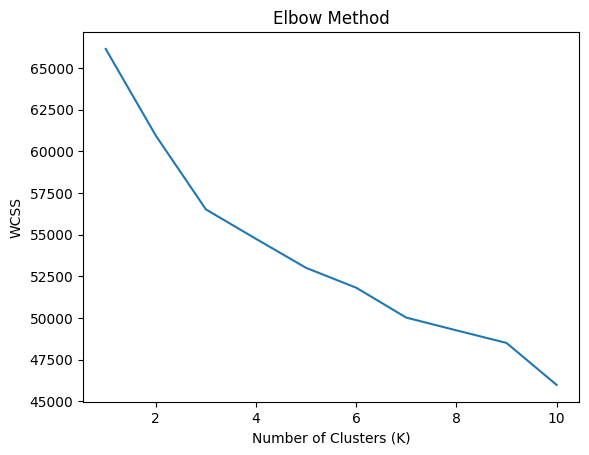

In [53]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []#Within Cluster Sum of Squares” means“How far are data points from their cluster center?”
# If employees in a cluster are:
# close together → small values of WCSS -->good grouping
# spread out → large value of WCSS -->bad grouping

for i in range(1, 11):#We are testing:# K = 1, K = 2,K = 3, ...,K = 10
    kmeans = KMeans(n_clusters=i, random_state=42)#If i = 3: model tries to make 3 employee groups
# If i = 5: model tries to make 5 groups
    kmeans.fit(df_scaled)#studies all employee data and tries to form clusters
    wcss.append(kmeans.inertia_)#wcss.append-->We store:“How good is this clustering?”
    #kmeans.inertia_  means:total distance of all points from cluster centers
plt.plot(range(1, 11), wcss)#X-axis = K values (1 to 10) and Y-axis = error (WCSS)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [54]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)#df['Cluster']-->new column added:
# each employee now has a group number (0–4)
# .fit_predictlearns patterns (fit) and assigns cluster labels (predict)


| Employee | Cluster |
| -------- | ------- |
| 1        | 2       |
| 2        | 0       |
| 3        | 4       |


# Example:


1.  Cluster 0:
   
> low income

> low satisfaction

> high overtime

>  HIGH RISK

2.  Cluster 1
   
> high income

> low overtime

>  stable job role

>  LOW RISK

# Clustring
*  Cluster 1:
High salary + low travel + high satisfaction → STABLE employees
*  Cluster 2:
Low salary + high travel + low satisfaction → RISK employees

# Analyze clusters

In [55]:
df.groupby('Cluster').mean()
#“For each employee group, what is the average behavior?”


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
Cluster,,,,,,,,,,,,,,,,,,,,,
0,33.996109,0.241245,795.906615,9.424125,2.774319,2.731518,66.626459,2.692607,1.225681,2.700389,...,0.0,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.447471,0.342412
1,35.194514,0.219451,800.009975,9.366584,2.915212,2.685786,65.149626,2.693267,2.039900,2.778055,...,0.0,0.000000,0.004988,0.000000,0.000000,0.00000,0.788030,0.206983,0.451372,0.354115
2,46.103448,0.056034,806.310345,8.745690,3.077586,2.655172,65.905172,2.732759,4.008621,2.685345,...,0.0,0.008621,0.426724,0.064655,0.344828,0.00000,0.043103,0.000000,0.525862,0.228448
3,35.500000,0.230769,757.923077,8.173077,2.884615,2.596154,64.173077,2.711538,1.480769,2.557692,...,1.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.538462,0.192308
4,35.768939,0.117424,810.276515,9.244318,2.909091,2.785985,66.259470,2.776515,1.693182,2.740530,...,0.0,0.000000,0.001894,0.246212,0.000000,0.55303,0.000000,0.000000,0.429924,0.335227


# Attrition% of each cluster

1. Attrition of Cluster 0 → 0.24

>  24% employees leave

2. Attrition of Cluster 2 → 0.05

> only 5% leave (VERY SAFE GROUP)

3. Attrition of Cluster 3 → 0.23

> moderate risk

# Visualize clusters

In [56]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

df['Cluster'].value_counts()

Cluster
4    528
1    401
0    257
2    232
3     52
Name: count, dtype: int64

**• Performed employee segmentation using K-Means clustering (K=5)
• Identified high-risk employee groups based on attrition rates and behavioral features
• Analyzed workforce patterns across salary, job satisfaction, and work-life balance
• Derived actionable HR insights for employee retention strategy**

# PCA + VISUAL CLUSTERS

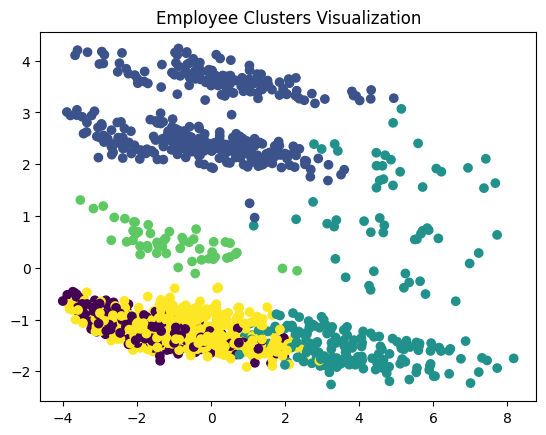

In [57]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)#reduces 45 features → 2 features Because we cannot visualize 45 dimensions.
df_pca = pca.fit_transform(df_scaled)

plt.scatter(df_pca[:,0], df_pca[:,1], c=df['Cluster'])
#scatter plot-->shows each employee as a dot
plt.title("Employee Clusters Visualization")
plt.show()

**Two different objects can have overlapping shadows not actually overlapping it happens because it is actually not in 2d it has 45 features so they are actually different in real space**

**“Some clusters show overlap due to similarity in employee features
medium salary,
average satisfaction,
similar roles and dimensionality reduction or some information is lost”**

**The separated clusters:
represent distinct employee groups
Example:
very high income OR
very low satisfaction OR
unique job roles**

# summarize graph
**“PCA visualization shows partial overlap between clusters, indicating some employee groups share similar characteristics. However, distinct clusters are still visible, confirming meaningful segmentation.”**

# ADD PREDICTION MODEL (CLASSIFICATION)

In [59]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# first model:logistic regression

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7210884353741497
              precision    recall  f1-score   support

           0       0.92      0.75      0.82       255
           1       0.25      0.56      0.35        39

    accuracy                           0.72       294
   macro avg       0.59      0.65      0.59       294
weighted avg       0.83      0.72      0.76       294



# random forest

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8775510204081632
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



# COMPARE Both Models:
| Model               | Accuracy | Recall (Leave = 1) | Meaning                     |
| ------------------- | -------- | ------------------ | --------------------------- |
| Logistic Regression | 72%      | **56%**            | Better at detecting risk    |
| Random Forest       | 88%      | 10%                | Misses most risky employees |

**We prefer HIGH RECALL
not high accuracy**

# Final Model Insight
Logistic Regression achieved an accuracy of 72%, but more importantly, it successfully identified 56% of employees who are likely to leave (recall).
Random Forest showed higher accuracy (88%) but failed to detect most employees at risk of attrition.
In HR analytics, recall is more important than accuracy because identifying employees who may leave is the main objective.
Therefore, Logistic Regression is more suitable for this attrition prediction task.

# PROJECT SUMMARY:

#  HR Attrition Analysis using K-Means Clustering & Machine Learning

---

##  Problem Statement

The objective of this project is to analyze employee data to understand **why employees leave the company (attrition)** and to identify hidden behavioral patterns using machine learning techniques.

Instead of directly predicting attrition first, we begin by grouping employees into similar behavior-based segments using clustering, then extend the analysis using predictive models.

---

##  Core Idea

Machine learning models cannot understand raw text or categories directly.
Therefore, we convert data into numerical format and transform it into meaningful patterns so algorithms can learn from it effectively.

---

##  Step 1: Data Understanding

The dataset includes employee-related features such as:

* Demographics: Age, Gender, Marital Status
* Job-related factors: Job Role, Department, Job Level
* Performance & satisfaction: Job Satisfaction, Environment Satisfaction
* Work history: Years at Company, Promotions, Experience
* Target variable: **Attrition (0 = stayed, 1 = left)**

 Attrition is the key variable representing employee turnover.

---

##  Step 2: Data Cleaning

We removed non-informative or constant columns:

* EmployeeCount (constant value)
* StandardHours (same for all employees)
* Over18 (no variation)
* EmployeeNumber (unique ID, no predictive value)

 These columns do not contribute to learning patterns, so removing them improves model efficiency.

---

##  Step 3: Feature Encoding (Categorical → Numerical)

Machine learning models require numerical input.

We handled categorical variables using:

* Label Encoding for binary variables:

  * Yes → 1, No → 0

* One-Hot Encoding for multi-class variables:

  * Department, Job Role, Education Field, etc.

 This ensures each category is represented in a machine-readable format without introducing bias.

---

##  Step 4: Feature Scaling

Different features have different ranges (e.g., Salary vs Satisfaction).

To avoid bias toward large-scale variables, we applied **StandardScaler**, which:

* Centers data around mean = 0
* Scales variance to 1
* Ensures fair contribution of all features

 This step is essential for distance-based algorithms like K-Means.

---

##  Step 5: K-Means Clustering

We applied K-Means clustering to group employees based on similarity.

### Concept:

K-Means divides data into K clusters such that:

* Employees in the same cluster are similar
* Employees in different clusters are different

---

##  Step 6: Optimal Cluster Selection (Elbow Method)

To find the optimal number of clusters:

* We tested K values from 1 to 10
* Measured WCSS (Within Cluster Sum of Squares)
* Identified the “elbow point” where improvement slows down

 Final selected value: **K = 5**

---

##  Step 7: Cluster Formation

Each employee was assigned to one of 5 clusters based on behavioral similarity.

These clusters represent different employee groups such as:

* High satisfaction, low risk employees
* Low satisfaction, high turnover risk employees
* Senior stable employees
* Entry-level high-risk employees

---

##  Step 8: Cluster Profiling (Business Insight)

We analyzed each cluster using average feature values.

### Key Findings:

* Some clusters show significantly higher attrition rates
* Job satisfaction and overtime strongly influence employee retention
* Income level and job level are indicators of employee stability

 This helps HR understand *types of employees rather than individuals*.

---

##  Step 9: Visualization using PCA

Since the dataset has many dimensions, we used PCA to reduce it to 2D for visualization.

### Interpretation:

* Each point = employee
* Each color = cluster group
* Closer points = similar employees

 Some overlap occurs due to similarity in behavioral patterns, which is expected in real-world data.

---

##  Step 10: Predictive Modeling (Supervised Learning)

To extend the analysis, we built classification models:

### Models used:

* Logistic Regression
* Random Forest Classifier

### Goal:

Predict whether an employee will leave (Attrition = 1)

---

##  Model Insights

### Logistic Regression:

* Lower accuracy (~72%)
* Higher recall for attrition detection (~56%)

### Random Forest:

* Higher accuracy (~88%)
* Very low recall for attrition (~10%)

---

##  Key Insight:

In HR problems, **recall is more important than accuracy**, because failing to identify employees who are likely to leave is more costly than false alarms.

 Therefore, Logistic Regression is more suitable for this problem.

---

##  Final Business Conclusions

* Employee attrition is strongly influenced by job satisfaction, overtime, and income level
* Clustering revealed hidden employee segments with different risk levels
* Predictive modeling helps identify employees likely to leave in advance
* Logistic Regression performs better for identifying at-risk employees

---

##  Project Outcome

* Built an end-to-end HR analytics system
* Combined unsupervised (clustering) and supervised (prediction) learning
* Extracted actionable insights for employee retention strategies
* Created a real-world machine learning workflow suitable for portfolio use

---

##  Skills Demonstrated

* Python (Pandas, NumPy)
* Data Preprocessing & Feature Engineering
* K-Means Clustering
* PCA Visualization
* Machine Learning Classification
* Model Evaluation (Accuracy, Precision, Recall, F1-score)

---

##  Final Summary

This project demonstrates how machine learning can be used not only to predict employee attrition but also to understand underlying workforce behavior patterns. The insights can help organizations design better retention strategies and improve employee satisfaction.
